# Parte 2 - Taller Diferenciación Robot
## Métodos Computacionales en Ingeniería
### Carlos Castillo

#### Cargue los mismos datos con NumPy y utilice una solución vectorizada

In [1]:
import time
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt


In [2]:
data = np.loadtxt("trayectoria_robot.csv", delimiter=",", skiprows=1)
t, x, y = data[:, 0], data[:, 1], data[:, 2]

In [3]:
t0 = time.perf_counter()
vx = np.gradient(x, t)                     # centrada interior, unilateral O(h) en extremos
vy = np.gradient(y, t)
v = np.sqrt(vx**2 + vy**2)
theta = np.unwrap(np.arctan2(vy, vx))
omega = np.gradient(theta, t)
t_exec = time.perf_counter() - t0

#### Variante con extremos de segundo orden


In [4]:
vx2, vy2 = np.gradient(x, t, edge_order=2), np.gradient(y, t, edge_order=2)
omega2 = np.gradient(np.unwrap(np.arctan2(vy2, vx2)), t, edge_order=2)
v2 = np.hypot(vx2, vy2)


#### Solución analítica

In [5]:
xd = 0.16*t + 0.18*np.cos(0.45*t);  yd = 0.50 + 0.135*np.sin(0.45*t)
xdd = 0.16 - 0.081*np.sin(0.45*t);  ydd = 0.06075*np.cos(0.45*t)
v_ex = np.hypot(xd, yd)
w_ex = (xd*ydd - yd*xdd) / (xd**2 + yd**2)


#### Comparación con Octave

/home/carlos/MCEI_2620/Octave/resultados_octave.csv True
Python | tiempo: 8.079e-04 s
Error max interior  v: 2.344e-04   omega: 5.905e-02
Error max global    v: 2.288e-02   omega: 1.357e-01
edge_order=2 global v: 2.344e-04   omega: 1.071e-02
Diferencia max vs Octave  v: 4.9e-11  omega: 4.9e-11


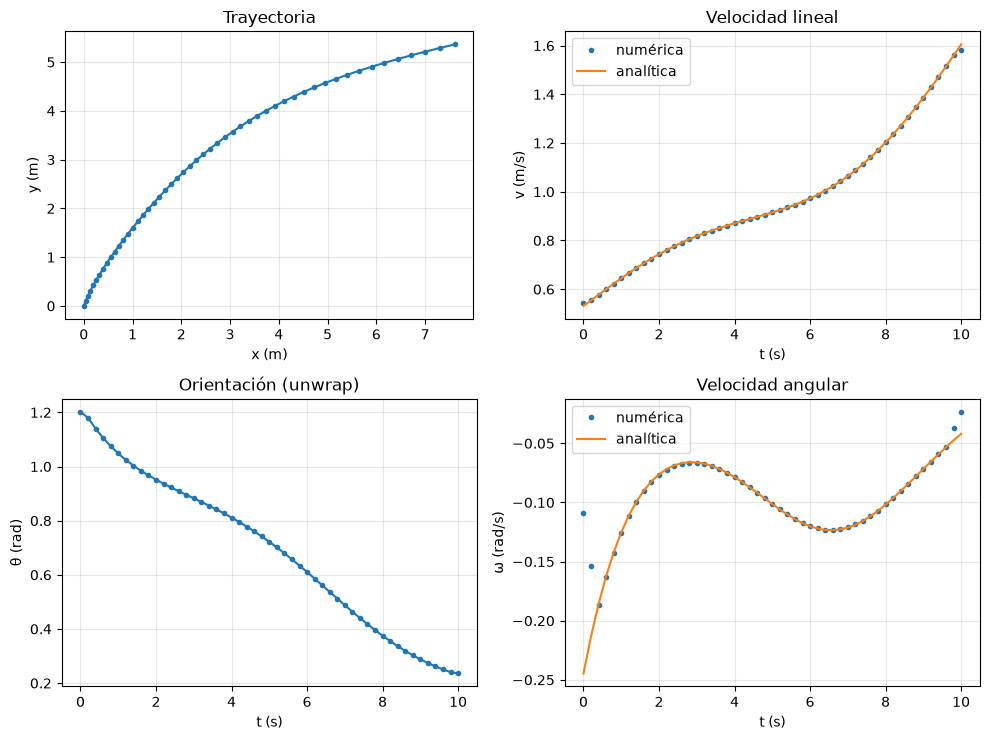

In [6]:
oct = np.loadtxt(r"/home/carlos/MCEI_2620/Octave/resultados_octave.csv", delimiter=",")

ruta_oct = Path.home() / "MCEI_2620" / "Octave" / "resultados_octave.csv"
print(ruta_oct, ruta_oct.exists())   
oct = np.loadtxt(ruta_oct, delimiter=",")

print(f"Python | tiempo: {t_exec:.3e} s")
print(f"Error max interior  v: {np.abs(v-v_ex)[1:-1].max():.3e}   omega: {np.abs(omega-w_ex)[1:-1].max():.3e}")
print(f"Error max global    v: {np.abs(v-v_ex).max():.3e}   omega: {np.abs(omega-w_ex).max():.3e}")
print(f"edge_order=2 global v: {np.abs(v2-v_ex).max():.3e}   omega: {np.abs(omega2-w_ex).max():.3e}")
print(f"Diferencia max vs Octave  v: {np.abs(v-oct[:,3]).max():.1e}  omega: {np.abs(omega-oct[:,5]).max():.1e}")

np.savetxt("resultados_python.csv", np.column_stack([t, vx, vy, v, theta, omega]),
           delimiter=",", fmt="%.10f")

fig, ax = plt.subplots(2, 2, figsize=(10, 7.5))
ax[0,0].plot(x, y, "o-", ms=3); ax[0,0].set_aspect("equal")
ax[0,0].set(xlabel="x (m)", ylabel="y (m)", title="Trayectoria")
ax[0,1].plot(t, v, "o", ms=3, label="numérica"); ax[0,1].plot(t, v_ex, label="analítica")
ax[0,1].set(xlabel="t (s)", ylabel="v (m/s)", title="Velocidad lineal"); ax[0,1].legend()
ax[1,0].plot(t, theta, "o-", ms=3)
ax[1,0].set(xlabel="t (s)", ylabel="θ (rad)", title="Orientación (unwrap)")
ax[1,1].plot(t, omega, "o", ms=3, label="numérica"); ax[1,1].plot(t, w_ex, label="analítica")
ax[1,1].set(xlabel="t (s)", ylabel="ω (rad/s)", title="Velocidad angular"); ax[1,1].legend()
for a in ax.flat: a.grid(alpha=.3)
fig.tight_layout(); 
fig.savefig("graficas_python_robot.png", dpi=110)
plt.show()

#### Pregunta 3: Efecto de h con ruido fijo

In [7]:
rng = np.random.default_rng(0)
sigma = 1e-3
print("\nh        err_v(sin ruido)  err_w(sin ruido)  err_v(ruido 1mm)  err_w(ruido 1mm)")
for h in [0.4, 0.2, 0.1, 0.05, 0.02, 0.01]:
    tt = np.arange(0, 10 + h/2, h)
    xx = 0.08*tt**2 + 0.40*np.sin(0.45*tt); yy = 0.50*tt + 0.30*(1-np.cos(0.45*tt))
    xd_ = 0.16*tt + 0.18*np.cos(0.45*tt); yd_ = 0.50 + 0.135*np.sin(0.45*tt)
    xdd_ = 0.16 - 0.081*np.sin(0.45*tt); ydd_ = 0.06075*np.cos(0.45*tt)
    ve, we = np.hypot(xd_, yd_), (xd_*ydd_ - yd_*xdd_)/(xd_**2 + yd_**2)
    res = []
    for s in (0, sigma):
        xn = xx + s*rng.standard_normal(tt.size); yn = yy + s*rng.standard_normal(tt.size)
        a, b = np.gradient(xn, tt), np.gradient(yn, tt)
        w = np.gradient(np.unwrap(np.arctan2(b, a)), tt)
        res += [np.sqrt(np.mean((np.hypot(a, b)-ve)[2:-2]**2)), np.sqrt(np.mean((w-we)[2:-2]**2))]
    print(f"{h:<8} {res[0]:<17.2e} {res[1]:<17.2e} {res[2]:<17.2e} {res[3]:.2e}")



h        err_v(sin ruido)  err_w(sin ruido)  err_v(ruido 1mm)  err_w(ruido 1mm)
0.4      6.83e-04          1.19e-03          1.65e-03          5.07e-03
0.2      1.69e-04          3.23e-04          4.30e-03          2.03e-02
0.1      4.19e-05          8.40e-05          6.28e-03          7.95e-02
0.05     1.04e-05          2.14e-05          1.54e-02          2.58e-01
0.02     1.66e-06          3.45e-06          3.67e-02          1.64e+00
0.01     4.15e-07          8.66e-07          7.02e-02          6.69e+00
